In [6]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import statistics as st

def get_df(day):
    file_name = f"prices_round_3_day_{day}.csv"
    return pd.read_csv(file_name, sep=';')

def get_product(df, product):
    return df[df['product'] == product].copy()

def get_first_two_dfs():
    first_df = get_df(0)
    second_df = get_df(1)
    second_df['timestamp'] = second_df['timestamp'] + 1000000
    return pd.concat([first_df, second_df])



In [7]:
df = get_first_two_dfs()

df_rock = get_product(df, 'VOLCANIC_ROCK')
df_call_9500 = get_product(df, "VOLCANIC_ROCK_VOUCHER_9500")
df_call_9750 = get_product(df, "VOLCANIC_ROCK_VOUCHER_9750")
df_call_10000 = get_product(df, "VOLCANIC_ROCK_VOUCHER_10000")
df_call_10250 = get_product(df, "VOLCANIC_ROCK_VOUCHER_10250")
df_call_10500 = get_product(df, "VOLCANIC_ROCK_VOUCHER_10500")

df_calls = {
    "CALL_9500": df_call_9500,
    "CALL_9750": df_call_9750,
    "CALL_10000": df_call_10000,
    "CALL_10250": df_call_10250,
    "CALL_10500": df_call_10500
}

In [8]:
df_call_9750

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
6,0,0,VOLCANIC_ROCK_VOUCHER_9750,754.0,19.0,NaN,NaN,NaN,NaN,755,19,NaN,NaN,NaN,NaN,754.5,0.0
24,0,100,VOLCANIC_ROCK_VOUCHER_9750,761.0,13.0,NaN,NaN,NaN,NaN,762,13,NaN,NaN,NaN,NaN,761.5,0.0
28,0,200,VOLCANIC_ROCK_VOUCHER_9750,764.0,15.0,NaN,NaN,NaN,NaN,765,15,NaN,NaN,NaN,NaN,764.5,0.0
50,0,300,VOLCANIC_ROCK_VOUCHER_9750,768.0,13.0,NaN,NaN,NaN,NaN,769,13,NaN,NaN,NaN,NaN,768.5,0.0
67,0,400,VOLCANIC_ROCK_VOUCHER_9750,760.0,15.0,NaN,NaN,NaN,NaN,761,15,NaN,NaN,NaN,NaN,760.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139932,1,1999500,VOLCANIC_ROCK_VOUCHER_9750,476.0,18.0,NaN,NaN,NaN,NaN,477,18,NaN,NaN,NaN,NaN,476.5,0.0
139957,1,1999600,VOLCANIC_ROCK_VOUCHER_9750,477.0,19.0,NaN,NaN,NaN,NaN,478,19,NaN,NaN,NaN,NaN,477.5,0.0
139959,1,1999700,VOLCANIC_ROCK_VOUCHER_9750,472.0,16.0,NaN,NaN,NaN,NaN,473,16,NaN,NaN,NaN,NaN,472.5,0.0
139981,1,1999800,VOLCANIC_ROCK_VOUCHER_9750,474.0,16.0,NaN,NaN,NaN,NaN,475,16,NaN,NaN,NaN,NaN,474.5,0.0


In [9]:
import plotly.graph_objects as go

# Compute midprice for each DataFrame
df_rock["mid_price"] = (df_rock["bid_price_1"] + df_rock["ask_price_1"]) / 2
df_call_9500["mid_price"] = (df_call_9500["bid_price_1"] + df_call_9500["ask_price_1"]) / 2
df_call_9750["mid_price"] = (df_call_9750["bid_price_1"] + df_call_9750["ask_price_1"]) / 2
df_call_10000["mid_price"] = (df_call_10000["bid_price_1"] + df_call_10000["ask_price_1"]) / 2
df_call_10250["mid_price"] = (df_call_10250["bid_price_1"] + df_call_10250["ask_price_1"]) / 2

# Create figure
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_rock['timestamp'], y=df_rock['mid_price'], name='VOLCANIC_ROCK Mid Price', line=dict(color='black')
))

fig.add_trace(go.Scatter(
    x=df_call_9500['timestamp'], y=df_call_9500['mid_price'], name='CALL_9500', yaxis='y2'
))
fig.add_trace(go.Scatter(
    x=df_call_9750['timestamp'], y=df_call_9750['mid_price'], name='CALL_9750', yaxis='y2'
))
fig.add_trace(go.Scatter(
    x=df_call_10000['timestamp'], y=df_call_10000['mid_price'], name='CALL_10000', yaxis='y2'
))
fig.add_trace(go.Scatter(
    x=df_call_10250['timestamp'], y=df_call_10250['mid_price'], name='CALL_10250', yaxis='y2'
))

# Update layout with two y-axes
fig.update_layout(
    title='VOLCANIC_ROCK and VOUCHER Call midprices',
    xaxis=dict(title='Timestamp'),
    yaxis=dict(title='VOLCANIC_ROCK Mid Price'),
    yaxis2=dict(title='VOUCHER Call Mid Prices', overlaying='y', side='right'),
    legend=dict(x=0.01, y=0.99),
    height=600,
    template='plotly_white'
)

fig.show()

In [10]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq


def black_scholes_call(spot, strike, time_to_expiry, volatility):
    d1 = (np.log(spot / strike) + (0.5 * volatility ** 2) * time_to_expiry) / (volatility * np.sqrt(time_to_expiry))
    d2 = d1 - volatility * np.sqrt(time_to_expiry)
    call_price = (spot * norm.cdf(d1) - strike * norm.cdf(d2))
    return call_price

def black_scholes_put(spot, strike, time_to_expiry, volatility):
    d1 = (np.log(spot / strike) + (0.5 * volatility ** 2) * time_to_expiry) / (volatility * np.sqrt(time_to_expiry))
    d2 = d1 - volatility * np.sqrt(time_to_expiry)
    put_price = (strike * norm.cdf(-d2) - spot * norm.cdf(-d1))
    return put_price

def delta(spot, strike, time_to_expiry, volatility):
    d1 = (np.log(spot) - np.log(strike) + (0.5 * volatility ** 2) * time_to_expiry) / (volatility * np.sqrt(time_to_expiry))
    return norm.cdf(d1)

def gamma(spot, strike, time_to_expiry, volatility):
    d1 = (np.log(spot) - np.log(strike) + (0.5 * volatility ** 2) * time_to_expiry) / (volatility * np.sqrt(time_to_expiry))
    return norm.pdf(d1)/(spot * volatility * np.sqrt(time_to_expiry))

def vega(spot, strike, time_to_expiry, volatility):
    d1 = (np.log(spot) - np.log(strike) + (0.5 * volatility ** 2) * time_to_expiry) / (volatility * np.sqrt(time_to_expiry))
    return norm.pdf(d1) * (spot * np.sqrt(time_to_expiry)) / 100

def implied_volatility(call_price, spot, strike, time_to_expiry):
    if call_price <= max(spot - strike, 0) + 1e-6:
        return 1e-3
    try:
        def equation(volatility):
            estimated_price = black_scholes_call(spot, strike, time_to_expiry, volatility)
            return estimated_price - call_price

        implied_vol = brentq(equation, 1e-5, 3.0, xtol=1e-10)
        return implied_vol
    except (ValueError, RuntimeError):
        return np.nan


strike_prices = {
    "CALL_9500": 9500,
    "CALL_9750": 9750,
    "CALL_10000": 10000,
    "CALL_10250": 10250,
    "CALL_10500": 10500
}

In [11]:
for label, df in df_calls.items():
    nan_count = df.isna().sum()
    print(nan_count)

day                    0
timestamp              0
product                0
bid_price_1          410
bid_volume_1         410
bid_price_2        19734
bid_volume_2       19734
bid_price_3        20000
bid_volume_3       20000
ask_price_1            0
ask_volume_1           0
ask_price_2        19378
ask_volume_2       19378
ask_price_3        19995
ask_volume_3       19995
mid_price            410
profit_and_loss        0
dtype: int64
day                    0
timestamp              0
product                0
bid_price_1          416
bid_volume_1         416
bid_price_2        19774
bid_volume_2       19774
bid_price_3        20000
bid_volume_3       20000
ask_price_1            0
ask_volume_1           0
ask_price_2        19441
ask_volume_2       19441
ask_price_3        19998
ask_volume_3       19998
mid_price            416
profit_and_loss        0
dtype: int64
day                    0
timestamp              0
product                0
bid_price_1          432
bid_volume_1         432

In [12]:
df_call_10000

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
4,0,0,VOLCANIC_ROCK_VOUCHER_10000,505.0,19.0,NaN,NaN,NaN,NaN,506,19,NaN,NaN,NaN,NaN,505.5,0.0
16,0,100,VOLCANIC_ROCK_VOUCHER_10000,515.0,13.0,NaN,NaN,NaN,NaN,516,13,NaN,NaN,NaN,NaN,515.5,0.0
39,0,200,VOLCANIC_ROCK_VOUCHER_10000,516.0,15.0,NaN,NaN,NaN,NaN,517,15,NaN,NaN,NaN,NaN,516.5,0.0
44,0,300,VOLCANIC_ROCK_VOUCHER_10000,521.0,13.0,NaN,NaN,NaN,NaN,522,13,NaN,NaN,NaN,NaN,521.5,0.0
62,0,400,VOLCANIC_ROCK_VOUCHER_10000,512.0,15.0,NaN,NaN,NaN,NaN,513,15,NaN,NaN,NaN,NaN,512.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139940,1,1999500,VOLCANIC_ROCK_VOUCHER_10000,237.0,18.0,NaN,NaN,NaN,NaN,238,18,NaN,NaN,NaN,NaN,237.5,0.0
139948,1,1999600,VOLCANIC_ROCK_VOUCHER_10000,237.0,19.0,NaN,NaN,NaN,NaN,238,19,NaN,NaN,NaN,NaN,237.5,0.0
139970,1,1999700,VOLCANIC_ROCK_VOUCHER_10000,234.0,16.0,NaN,NaN,NaN,NaN,235,16,NaN,NaN,NaN,NaN,234.5,0.0
139977,1,1999800,VOLCANIC_ROCK_VOUCHER_10000,237.0,16.0,NaN,NaN,NaN,NaN,238,16,NaN,NaN,NaN,NaN,237.5,0.0


In [13]:
df_call_10500.columns

Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss'],
      dtype='object')

In [14]:
time_to_expiry = 5

underlying_mid = (df_rock["bid_price_1"] + df_rock["ask_price_1"]) / 2

for label, df in df_calls.items():
    strike_price = strike_prices[label]
    print(label)

    df["mid_price_rock"] = underlying_mid.values[:len(df)]
    
    df["implied_vol"] = df.apply(lambda row: implied_volatility(row["mid_price"], row["mid_price_rock"], strike_price, time_to_expiry), axis=1)
    df["delta"] = df.apply(lambda row: delta(row["mid_price_rock"], strike_price, time_to_expiry, row["implied_vol"]), axis=1)
    df["gamma"] = df.apply(lambda row: gamma(row["mid_price_rock"], strike_price, time_to_expiry, row["implied_vol"]), axis=1)
    df["vega"] = df.apply(lambda row: vega(row["mid_price_rock"], strike_price, time_to_expiry, row["implied_vol"]), axis=1)


CALL_9500
CALL_9750
CALL_10000
CALL_10250
CALL_10500


In [15]:
df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,mid_price_rock,implied_vol,delta,gamma,vega
0,0,0,VOLCANIC_ROCK_VOUCHER_10500,99.0,19.0,NaN,NaN,NaN,NaN,100,...,NaN,NaN,NaN,99.5,0.0,10503.0,0.010461,0.509537,0.001623,93.666504
22,0,100,VOLCANIC_ROCK_VOUCHER_10500,102.0,13.0,NaN,NaN,NaN,NaN,103,...,NaN,NaN,NaN,102.5,0.0,10510.0,0.010396,0.520964,0.001631,93.626243
36,0,200,VOLCANIC_ROCK_VOUCHER_10500,104.0,15.0,NaN,NaN,NaN,NaN,105,...,NaN,NaN,NaN,104.5,0.0,10513.0,0.010442,0.525781,0.001622,93.586591
49,0,300,VOLCANIC_ROCK_VOUCHER_10500,106.0,13.0,NaN,NaN,NaN,NaN,107,...,NaN,NaN,NaN,106.5,0.0,10517.5,0.010401,0.533166,0.001625,93.498209
61,0,400,VOLCANIC_ROCK_VOUCHER_10500,102.0,15.0,NaN,NaN,NaN,NaN,103,...,NaN,NaN,NaN,102.5,0.0,10509.5,0.010424,0.520120,0.001627,93.632010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139933,1,1999500,VOLCANIC_ROCK_VOUCHER_10500,9.0,18.0,NaN,NaN,NaN,NaN,10,...,NaN,NaN,NaN,9.5,0.0,10224.5,0.009109,0.097635,0.000828,39.426976
139949,1,1999600,VOLCANIC_ROCK_VOUCHER_10500,9.0,19.0,NaN,NaN,NaN,NaN,10,...,NaN,NaN,NaN,9.5,0.0,10225.5,0.009085,0.097847,0.000832,39.493551
139964,1,1999700,VOLCANIC_ROCK_VOUCHER_10500,9.0,16.0,NaN,NaN,NaN,NaN,10,...,NaN,NaN,NaN,9.5,0.0,10222.0,0.009171,0.097110,0.000819,39.261797
139979,1,1999800,VOLCANIC_ROCK_VOUCHER_10500,9.0,16.0,NaN,NaN,NaN,NaN,10,...,NaN,NaN,NaN,9.5,0.0,10223.5,0.009134,0.097424,0.000825,39.360690


In [16]:
df_call_10000

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,mid_price_rock,implied_vol,delta,gamma,vega
4,0,0,VOLCANIC_ROCK_VOUCHER_10000,505.0,19.0,NaN,NaN,NaN,NaN,506,...,NaN,NaN,NaN,505.5,0.0,10503.0,0.011254,0.975161,0.000220,13.651750
16,0,100,VOLCANIC_ROCK_VOUCHER_10000,515.0,13.0,NaN,NaN,NaN,NaN,516,...,NaN,NaN,NaN,515.5,0.0,10510.0,0.013092,0.956713,0.000299,21.589673
39,0,200,VOLCANIC_ROCK_VOUCHER_10000,516.0,15.0,NaN,NaN,NaN,NaN,517,...,NaN,NaN,NaN,516.5,0.0,10513.0,0.012102,0.968717,0.000248,16.559404
44,0,300,VOLCANIC_ROCK_VOUCHER_10000,521.0,13.0,NaN,NaN,NaN,NaN,522,...,NaN,NaN,NaN,521.5,0.0,10517.5,0.012478,0.965792,0.000258,17.833736
62,0,400,VOLCANIC_ROCK_VOUCHER_10000,512.0,15.0,NaN,NaN,NaN,NaN,513,...,NaN,NaN,NaN,512.5,0.0,10509.5,0.011721,0.971883,0.000234,15.151330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139940,1,1999500,VOLCANIC_ROCK_VOUCHER_10000,237.0,18.0,NaN,NaN,NaN,NaN,238,...,NaN,NaN,NaN,237.5,0.0,10224.5,0.008820,0.871947,0.001038,47.861443
139948,1,1999600,VOLCANIC_ROCK_VOUCHER_10000,237.0,19.0,NaN,NaN,NaN,NaN,238,...,NaN,NaN,NaN,237.5,0.0,10225.5,0.008634,0.877936,0.001026,46.291067
139970,1,1999700,VOLCANIC_ROCK_VOUCHER_10000,234.0,16.0,NaN,NaN,NaN,NaN,235,...,NaN,NaN,NaN,234.5,0.0,10222.0,0.008648,0.873930,0.001048,47.332808
139977,1,1999800,VOLCANIC_ROCK_VOUCHER_10000,237.0,16.0,NaN,NaN,NaN,NaN,238,...,NaN,NaN,NaN,237.5,0.0,10223.5,0.008998,0.866201,0.001049,49.330720


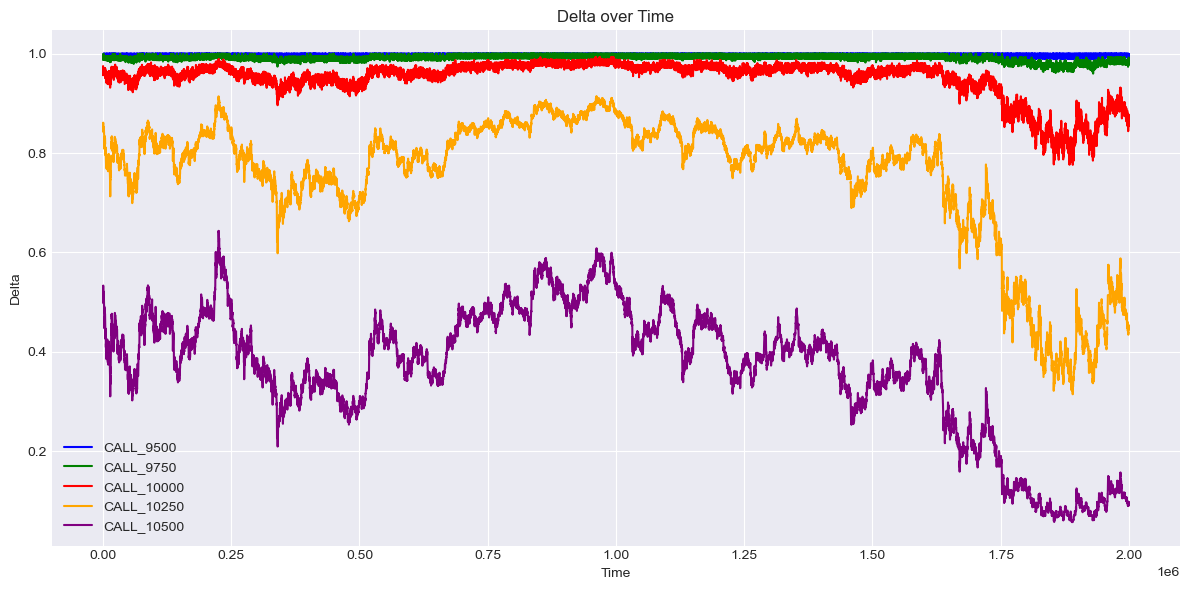

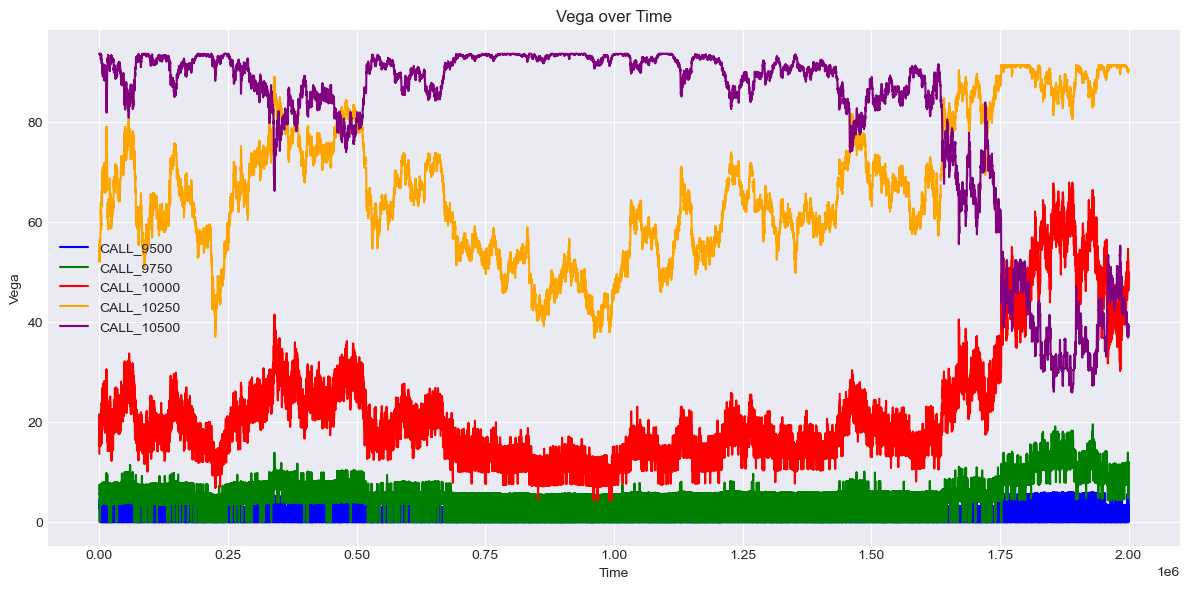

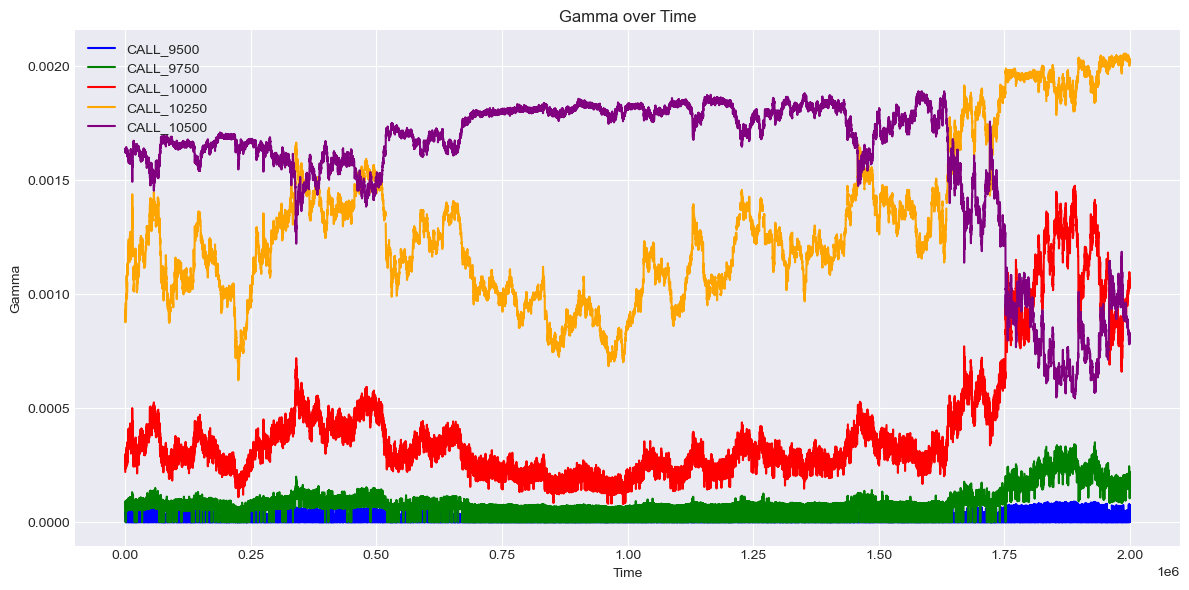

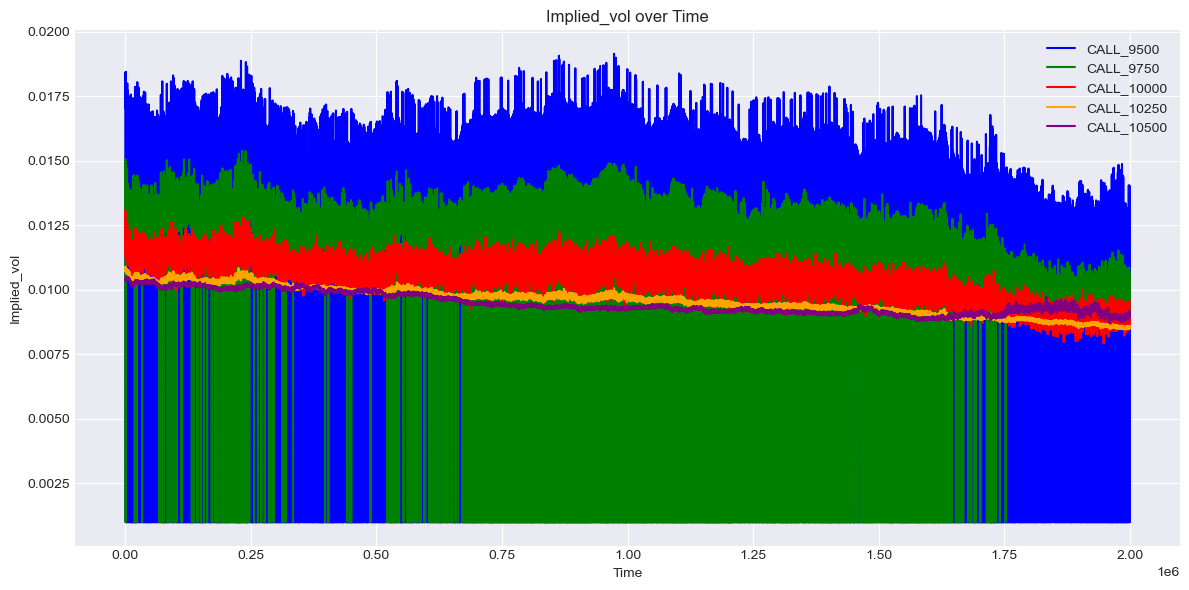

In [17]:
import matplotlib.pyplot as plt

# Plot settings
plt.style.use("seaborn-v0_8-darkgrid")
colors = ["blue", "green", "red", "orange", "purple"]
labels = list(df_calls.keys())

# Metrics to plot
metrics = ["delta", "vega", "gamma", "implied_vol"]

for metric in metrics:
    plt.figure(figsize=(12, 6))
    for i, (label, df) in enumerate(df_calls.items()):
        x = df.timestamp
        y = df[metric]
        plt.plot(x, y, label=label, color=colors[i % len(colors)])
    
    plt.title(f"{metric.capitalize()} over Time")
    plt.xlabel("Time")
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.tight_layout()
    plt.show()

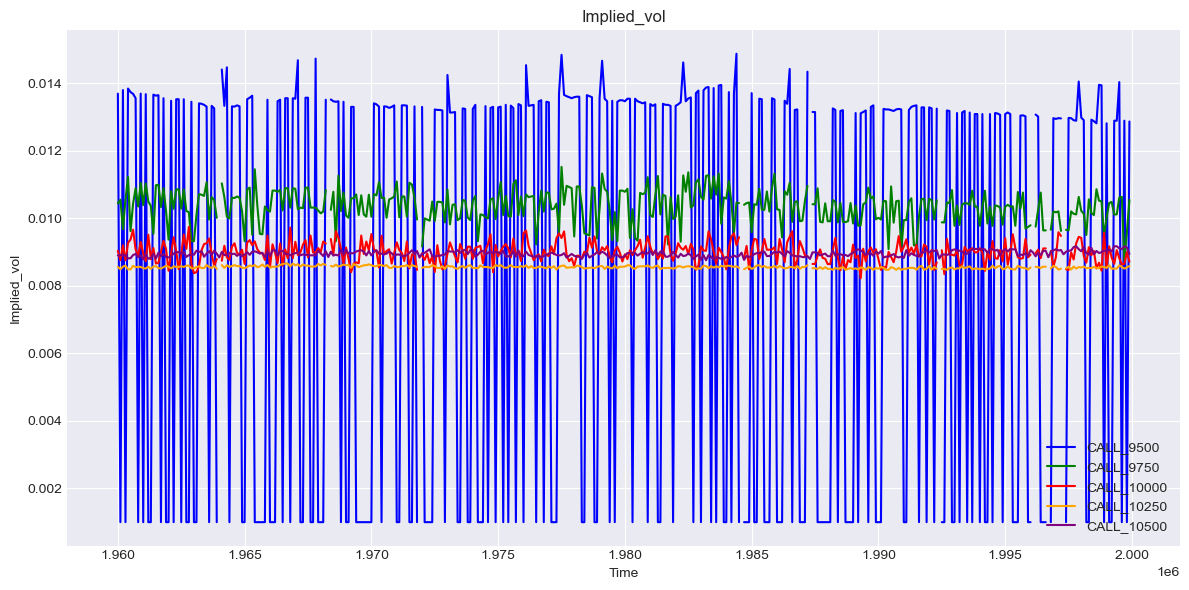

In [18]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")
colors = ["blue", "green", "red", "orange", "purple"]
labels = list(df_calls.keys())

metrics = ["implied_vol"]

for metric in metrics:
    plt.figure(figsize=(12, 6))
    for i, (label, df) in enumerate(df_calls.items()):
        x = df.timestamp[-400:]
        y = df[metric][-400:]
        plt.plot(x, y, label=label, color=colors[i % len(colors)])
    
    plt.title(f"{metric.capitalize()}")
    plt.xlabel("Time")
    plt.ylabel(metric.capitalize())
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

In [19]:
means = {}
stds = {}
for i, (label, df) in enumerate(df_calls.items()):
    implied_vol_mean = df['implied_vol'].mean()
    implied_vol_std = df['implied_vol'].std()

    means[f'{label}'] = implied_vol_mean
    stds[f'{label}'] = implied_vol_std

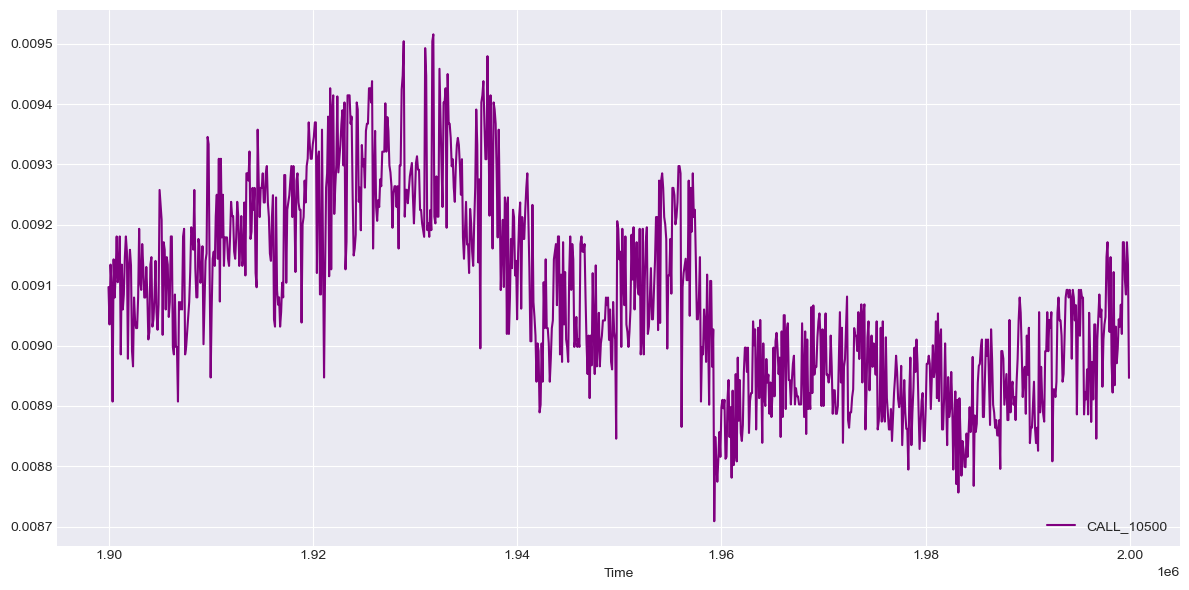

In [20]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")
colors = ["blue", "green", "red", "orange", "purple"]
labels = list(df_calls.keys())

metric = ["implied_vol"]

plt.figure(figsize=(12, 6))
x = df_call_10500.timestamp[-1000:]
y = df_call_10500[metric][-1000:]
plt.plot(x, y, label=label, color=colors[i % len(colors)])

plt.xlabel("Time")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [21]:

plotting_dfs = {
    "CALL_10500": df_call_9750
}

In [56]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

EXPIRY_TIMESTAMP = 4_000_000  
base_volatility = []

all_timestamps = sorted(set.intersection(*[
    set(df_call['timestamp'].dropna().astype(int)) for df_call in df_calls.values()
]))

timestamps_to_plot = all_timestamps


rolling_mean_base_vol = []
window_data = []
window_size = 5

for t in timestamps_to_plot:
    m_list = []
    v_list = []
    strikes_used = []

    for call_name, df_call in df_calls.items():
        K = strike_prices[call_name]
        row = df_call[df_call['timestamp'] == t]

        if row.empty:
            continue

        St = row['mid_price_rock'].values[0]
        Vt = row['mid_price'].values[0]

        if pd.isna(St) or pd.isna(Vt) or St <= 0 or Vt <= 0:
            continue

        TTE = (EXPIRY_TIMESTAMP - t) / 1_000_000
        if TTE <= 0:
            continue

        m_t = np.log(K / St) / np.sqrt(TTE)
        v_t = implied_volatility(Vt, St, K, TTE)

        if np.isnan(v_t) or v_t > 5:
            continue

        m_list.append(m_t)
        v_list.append(v_t)
        strikes_used.append(K)

    if len(m_list) < 3:
        base_volatility.append(np.nan)
        continue

    
    m_array = np.array(m_list).reshape(-1, 1)
    m_squared = np.hstack([m_array**2, m_array, np.ones_like(m_array)])

    window_data.append([m_list, v_list])

    rolling_ms = []
    rolling_vs = []

    if len(window_data)>window_size:
        window_data.pop(0)
        for data in window_data:
            rolling_ms += data[0]
            rolling_vs += data[1]

        rolling_ms_array = np.array(rolling_ms).reshape(-1,1)
        rolling_ms_sqr = np.hstack([rolling_ms_array**2, rolling_ms_array, np.ones_like(rolling_ms_array)])

        reg = LinearRegression().fit(rolling_ms_sqr, rolling_vs)

        if reg.coef_[0] >= 0:
            rolling_mean_base_vol.append(reg.intercept_)
        else:
            rolling_mean_base_vol.append(np.nan)


    reg = LinearRegression().fit(m_squared, v_list)

    if reg.coef_[0] >= 0:
        base_volatility.append(reg.intercept_)
    else:
        base_volatility.append(np.nan)


    '''
    m_plot = np.linspace(min(m_list)-0.1, max(m_list)+0.1, 100).reshape(-1, 1)
    m_plot_squared = np.hstack([m_plot**2, m_plot, np.ones_like(m_plot)])
    v_fit = reg.predict(m_plot_squared)

    
    plt.figure(figsize=(10, 6))
    plt.scatter(m_list, v_list, color='blue', label='Implied Vols')
    
    for m_val, v_val, strike in zip(m_list, v_list, strikes_used):
        plt.annotate(f"K={strike}", (m_val, v_val), textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8)

    plt.plot(m_plot, v_fit, color='red', label='Parabolic Fit')
    plt.title(f"Volatility Smile at Timestamp {t}")
    plt.xlabel(r"$m_t = \frac{\log(K/S_t)}{\sqrt{TTE}}$")
    plt.ylabel("Implied Volatility")
    plt.legend()
    plt.grid(True)
    plt.show()
    '''
    
base_volatility = pd.Series(base_volatility).ffill().tolist()
rolling_mean_base_vol = pd.Series(rolling_mean_base_vol).ffill().tolist()

<>:90: SyntaxWarning:

invalid escape sequence '\l'

<>:90: SyntaxWarning:

invalid escape sequence '\l'

C:\Users\olesc\AppData\Local\Temp\ipykernel_60216\2106458335.py:90: SyntaxWarning:

invalid escape sequence '\l'



19556
20000


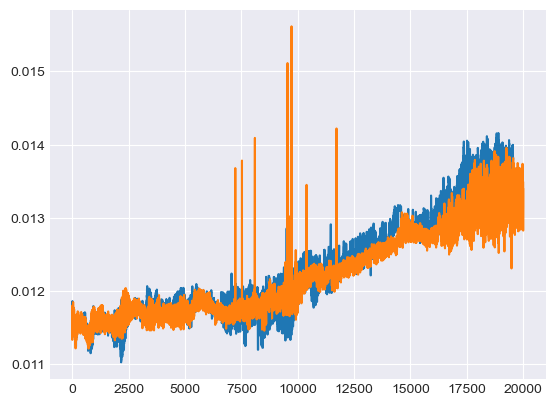

In [57]:
print(len(rolling_mean_base_vol))
print(len(base_volatility))

plt.plot(rolling_mean_base_vol)
plt.plot(base_volatility)

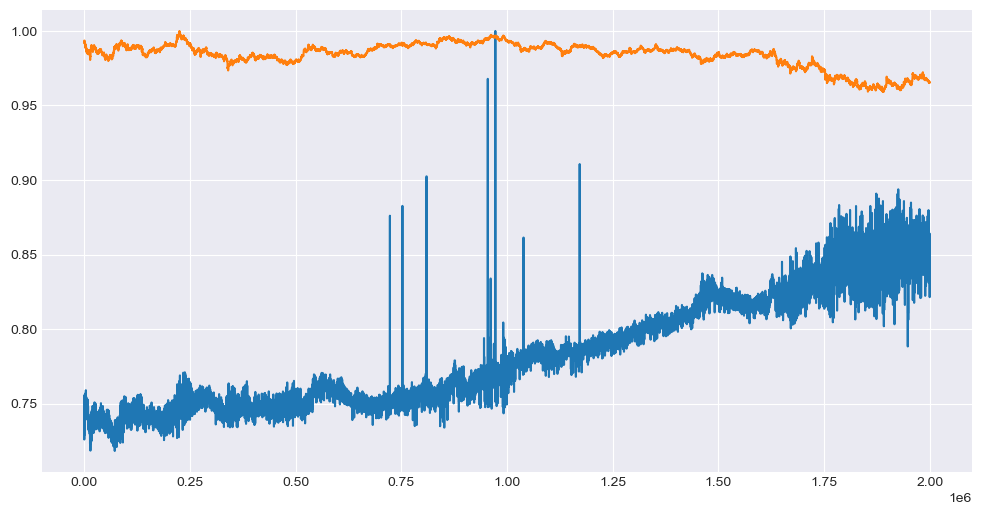

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(timestamps_to_plot, np.array(base_volatility)/max(base_volatility))
plt.plot(timestamps_to_plot, df_rock['mid_price']/max(df_rock['mid_price']))

In [46]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_rock['timestamp'], y=df_rock['mid_price'], name='VOLCANIC_ROCK Mid Price', line=dict(color='black')
))

fig.add_trace(go.Scatter(
    x=df_rock['timestamp'], y=base_volatility, name='BASE_VOL', yaxis='y2'
))

fig.update_layout(
    title='VOLCANIC_ROCK and BASE_VOL',
    xaxis=dict(title='Timestamp'),
    yaxis=dict(title='VOLCANIC_ROCK Mid Price'),
    yaxis2=dict(title='BASE_VOL', overlaying='y', side='right'),
    legend=dict(x=0.01, y=0.99),
    height=600,
    template='plotly_white'
)

fig.show()

In [ ]:
from scipy.signal import find_peaks


vol_series = np.array(base_volatility)
timestamps_used = np.array(timestamps_to_plot[:len(vol_series)])

valid = ~np.isnan(vol_series)
vol_series = vol_series[valid]
timestamps_used = timestamps_used[valid]

# -----------------------
# 1. Volatility Trend Detection
# -----------------------
vol_gradient = np.gradient(vol_series)
trend_signal = np.where(vol_gradient > 0.0001, "Long Vol", "Short Vol")

plt.figure(figsize=(10, 4))
plt.plot(timestamps_used, vol_series, label='ATM Implied Vol')
plt.title("ATM Volatility over Time")
plt.xlabel("Timestamp")
plt.ylabel("Implied Vol at m=0")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------
# 2. Volatility Jump Detection
# -----------------------
jump_threshold = 0.001
jumps = np.where(np.abs(np.diff(vol_series)) > jump_threshold)[0]

print("Large Volatility Jumps Detected:")
for j in jumps:
    print(f"Jump at t={timestamps_used[j+1]}: {vol_series[j]:.3f} -> {vol_series[j+1]:.3f}")

In [ ]:
# -----------------------
# 3. Mean Reversion Detection
# -----------------------
vol_s = pd.Series(vol_series, index=timestamps_used)
rolling_mean = vol_s.rolling(window=3, min_periods=1).mean()
deviation = vol_s - rolling_mean
reversion_signal = np.where(deviation > 0.03, "Short Vol",
                            np.where(deviation < -0.03, "Long Vol", "Neutral"))

plt.figure(figsize=(10, 4))
plt.plot(vol_s, label="ATM Volatility")
plt.plot(rolling_mean, label="Rolling Mean (3)", linestyle="--")
plt.title("Volatility Mean Reversion Signal")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()